# Linear Regression Baseline Notebook (Supplemental to Approach 1)

Supplemental baseline model requested by Jordan (Slack, 2026-07-30): **not** a replacement for `xgboost_regressor.ipynb` (Approach 1) — it runs alongside it, using the exact same features and target so the *only* thing being compared is the algorithm itself (a plain straight-line model vs. XGBoost's tree ensemble). No ASPL (`pos`/`neg`) features here, same as Approach 1.

Per Jordan's confirmation in Slack (2026-07-29) that the team has dropped the `training_tickers.csv` 1,000-ticker sample ('professor talked about how it would've made our training set too little'), this trains on the **full stock universe** -- but keeps Jordan's existing **2014-01-01 train/test split date** (train: 2010-2013, test: 2014-2025) so results land on the same test window as `xgboost_regressor.ipynb` / `xgboost_avsp_regressor.ipynb` / `xgboost_avsp_classifier.ipynb` once those get re-run without the ticker sample. As of this writing none of Jordan's 3 notebooks have actually been re-run that way yet (still 1,000-ticker/`origin/jordan`@`a1ffbd8`), so this is not yet comparable to a finished number on his side -- only to whatever he produces next under this same full-universe/2014-01-01 scheme.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle as pkl

##### Constants

In [1]:
NUM_COL = 'true_prc'
DATE_COL = 'dlycaldt'
TICKER_COL1 = 'permno'
TICKER_COL2 = 'ticker'
SPLIT_DATE = "2014-01-01"      # matches Jordan's existing notebooks' split date; full universe on both sides now
START_BALANCE = 1000.0
EXIT_PROP = 1.0

##### Data Prep

In [1]:
# Read the CIZ-format CRSP daily stock file directly from the year-partitioned parquet
# files under ./data/dsf/ (one folder per year, e.g. year=2010/data.parquet) -- this is
# the raw `SELECT * FROM crsp.dsf_v2` pull from crsp_batch_download.ipynb, so no reformatting
# is needed and column names are native CIZ names.
NEEDED_COLS = [
    TICKER_COL1, TICKER_COL2, DATE_COL,
    'dlyclose', 'dlycap', 'dlyprc', 'dlyvol', 'dlyret', 'dlyprcvol', 'dlyask', 'dlybid'
]
data = pd.read_parquet('./data/dsf/', engine='pyarrow', columns=NEEDED_COLS)
data[DATE_COL] = pd.to_datetime(data[DATE_COL])
data = data.dropna(subset='dlyclose').reset_index(drop=True)
data['dlyvol'] = data['dlyvol'].fillna(0)

# Same true_prc definition used across the whole project (average_shortest_paths_crsp.ipynb,
# xgboost_regressor.ipynb, etc.): market-cap-derived price so it's split/share-count consistent.
data['tot_shares'] = (data['dlycap'] / data['dlyprc']).round(0)
data[NUM_COL] = data['dlyclose'] * data['tot_shares'] / 1_000_000
data.head()

   permno ticker   dlycaldt  dlyclose  ...  dlyask  dlybid  tot_shares  true_prc
0   10001   EGAS 2010-01-04     10.25  ...   10.26   10.21      4361.0    0.0447
1   10002   BTFG 2010-01-04       3.1  ...    3.25    3.01     17634.0  0.054665
2   10025   AEPI 2010-01-04     39.56  ...   39.62   39.54      6852.0  0.271065
3   10026   JJSF 2010-01-04      40.2  ...    40.2   40.13     18374.0  0.738635
4   10028   DGSE 2010-01-04    1.4001  ...    1.42     1.4      9834.0  0.013769

[5 rows x 13 columns]


##### Feature Engineering

Identical 19 features + target definition to `xgboost_regressor.ipynb` (no ASPL) -- this is the whole point of a "supplemental baseline": same inputs, different algorithm.

In [1]:
reg_df = data.sort_values([TICKER_COL1, TICKER_COL2, DATE_COL]).copy()

# Target: next-day (t+1) true_prc
reg_df["target"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].shift(-1)

for lag in [1, 2, 3, 5, 10, 20]:
    reg_df[f"lag_prc_{lag}"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].shift(lag)

for lag in [1, 2, 3, 5, 10]:
    reg_df[f"lag_ret_{lag}"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyret"].shift(lag)

for win in [5, 10, 20, 50]:
    reg_df[f"ma_{win}"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].transform(lambda x: x.rolling(win).mean())

reg_df["vol_20"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyret"].transform(lambda x: x.rolling(20).std())
reg_df["vol_ma_20"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyprcvol"].transform(lambda x: x.rolling(20).mean())
reg_df["vol_ratio"] = reg_df["dlyprcvol"] / reg_df["vol_ma_20"]
reg_df["spread"] = reg_df["dlyask"] - reg_df["dlybid"]

FEATURES = ["lag_prc_1", "lag_prc_2", "lag_prc_3", "lag_prc_5", "lag_prc_10", "lag_prc_20",
            "lag_ret_1", "lag_ret_2", "lag_ret_3", "lag_ret_5", "lag_ret_10",
            "ma_5", "ma_10", "ma_20", "ma_50", "vol_20", "vol_ratio", "spread", "dlyvol"]

reg_df = reg_df[[TICKER_COL1, TICKER_COL2, DATE_COL, NUM_COL, "target"] + FEATURES]

# LinearRegression (unlike XGBoost) can't handle inf/NaN, so clean those up explicitly --
# vol_ratio can be inf when a ticker's 20-day dollar-volume average is 0.
reg_df = reg_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
reg_df.head()

   permno ticker   dlycaldt  true_prc  ...    vol_20  vol_ratio  spread   dlyvol
0   10001   EGAS 2010-03-16  0.043479  ...  0.006309   0.733021    0.02   6500.0
1   10001   EGAS 2010-03-17  0.043562  ...  0.005973   0.928911    0.03   8500.0
2   10001   EGAS 2010-03-18  0.044177  ...  0.006583   2.569359    0.03  26000.0
3   10001   EGAS 2010-03-19  0.043784  ...  0.006765   0.849353    0.03   8800.0
4   10001   EGAS 2010-03-22   0.04361  ...  0.006624   0.611996    0.05   6200.0

[5 rows x 24 columns]


##### Train/Test Split

Full stock universe on both sides (no 1,000-ticker sampling), time-based split at 2014-01-01, matching Jordan's existing notebooks' split date.

In [1]:
train_df = reg_df[reg_df[DATE_COL] < SPLIT_DATE]
test_df = reg_df[reg_df[DATE_COL] >= SPLIT_DATE]

X_train = train_df[FEATURES]
y_train = train_df["target"]
X_test = test_df[FEATURES]
y_test = test_df["target"]

print(f"Train rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print(f"Train tickers: {train_df[TICKER_COL1].nunique():,} | Test tickers: {test_df[TICKER_COL1].nunique():,}")
print(f"Train date range: {train_df[DATE_COL].min().date()} to {train_df[DATE_COL].max().date()}")
print(f"Test date range: {test_df[DATE_COL].min().date()} to {test_df[DATE_COL].max().date()}")

Train rows: 3,503,648 | Test rows: 11,115,963
Train tickers: 4,669 | Test tickers: 6,785
Train date range: 2010-03-16 to 2013-12-31
Test date range: 2014-01-02 to 2025-12-30


##### Baseline Model

In [1]:
# Plain OLS linear regression -- unlike XGBoost, there are no hyperparameters to tune here,
# which is exactly what makes this a "simplest possible baseline".
model = LinearRegression()
model.fit(X_train, y_train)
preds = model.predict(X_test)

with open("./models/baseline_linear_reg_model_fulluniv_2014split_073026_01.pkl", "wb") as f:
    pkl.dump(model, f)

print(f"MAE: {mean_absolute_error(y_test, preds):.4f}")
print(f"R^2:  {r2_score(y_test, preds):.4f}")

MAE: 0.1553
R^2:  0.9995


##### Feature Coefficients

A strength of a linear model over XGBoost: each feature's effect on the prediction is directly readable as a single number, no SHAP/permutation-importance step required.

In [1]:
coef_df = pd.DataFrame({"feature": FEATURES, "coefficient": model.coef_}) \
    .sort_values("coefficient", key=abs, ascending=False).reset_index(drop=True)
print(coef_df)
print(f"Intercept: {model.intercept_:.4f}")

       feature   coefficient
0         ma_5  3.083994e+00
1    lag_prc_3 -9.132499e-01
2    lag_prc_2 -6.730860e-01
3    lag_ret_3  3.685240e-01
4    lag_prc_5 -3.028594e-01
5    lag_prc_1 -2.358131e-01
6       vol_20 -4.747683e-02
7        ma_10  4.591788e-02
8   lag_ret_10  2.807694e-02
9        ma_20  1.639569e-02
10   lag_ret_1  1.599243e-02
11  lag_prc_10 -1.547040e-02
12   lag_ret_2  1.312428e-02
13  lag_prc_20 -3.976925e-03
14   lag_ret_5  3.298865e-03
15       ma_50 -1.330087e-03
16   vol_ratio  2.872048e-04
17      spread -2.032955e-04
18      dlyvol -2.457433e-10
Intercept: 0.0020


##### Trading Strategy

In [1]:
# Same buy/sell rule as trade_strat_single() in xgboost_regressor.ipynb: go all-in if the
# predicted next-day price is >= today's price, otherwise exit exit_prop of the position.
# Implemented with plain numpy arrays (instead of DataFrame.iterrows()) for speed, since this
# runs over the full ~4,700-ticker test-period universe rather than a 1,000-ticker sample.
def trade_strat_single(price, pred, curr_b=START_BALANCE, exit_prop=EXIT_PROP):
    curr_vol = 0.0
    n = len(price)
    out = np.empty(n)
    for i in range(n):
        p = price[i]
        if pred[i] >= p:
            if curr_b > 0:
                curr_vol += curr_b / p
                curr_b = 0.0
        else:
            if curr_vol > 0:
                shares_sold = exit_prop * curr_vol
                curr_b += shares_sold * p
                curr_vol -= shares_sold
        out[i] = curr_b + curr_vol * p
    return out


def trade_strat(preds_df):
    results = []
    for (permno, ticker), grp in preds_df.groupby([TICKER_COL1, TICKER_COL2], sort=False):
        price = grp[NUM_COL].to_numpy()
        pred = grp['pred'].to_numpy()
        strat_ret = trade_strat_single(price, pred)
        start_vol = START_BALANCE / price[0]
        hold_ret = start_vol * price
        results.append(pd.DataFrame({
            TICKER_COL1: permno,
            TICKER_COL2: ticker,
            DATE_COL: grp[DATE_COL].to_numpy(),
            'strat_ret': strat_ret,
            'hold_ret': hold_ret,
        }))
    return pd.concat(results, ignore_index=True)

In [1]:
preds_df = test_df[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL, "target"]].copy()
preds_df['pred'] = preds
preds_df = preds_df.sort_values([TICKER_COL1, TICKER_COL2, DATE_COL]).reset_index(drop=True)

ret_df = trade_strat(preds_df)
ret_df.to_csv("./data/linear_reg_baseline_model_returns_fulluniv_2014split_073026_01.csv", index=False)
print(f"ret_df shape: {ret_df.shape}, tickers simulated: {ret_df[TICKER_COL1].nunique():,}")

ret_df shape: (11115963, 5), tickers simulated: 6,785


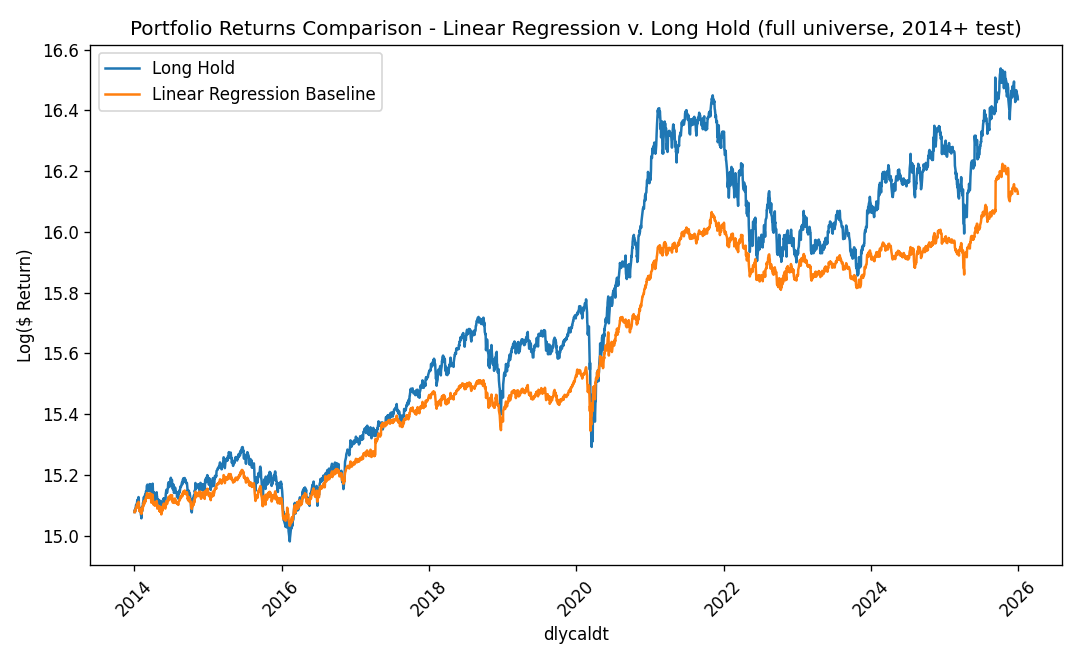

In [1]:
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret": "sum", "hold_ret": "sum"})

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold", ax=ax)
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="Linear Regression Baseline Strategy", ax=ax)
ax.set_title("Portfolio Returns Comparison - Linear Regression Baseline v. Long Hold")
ax.set_ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

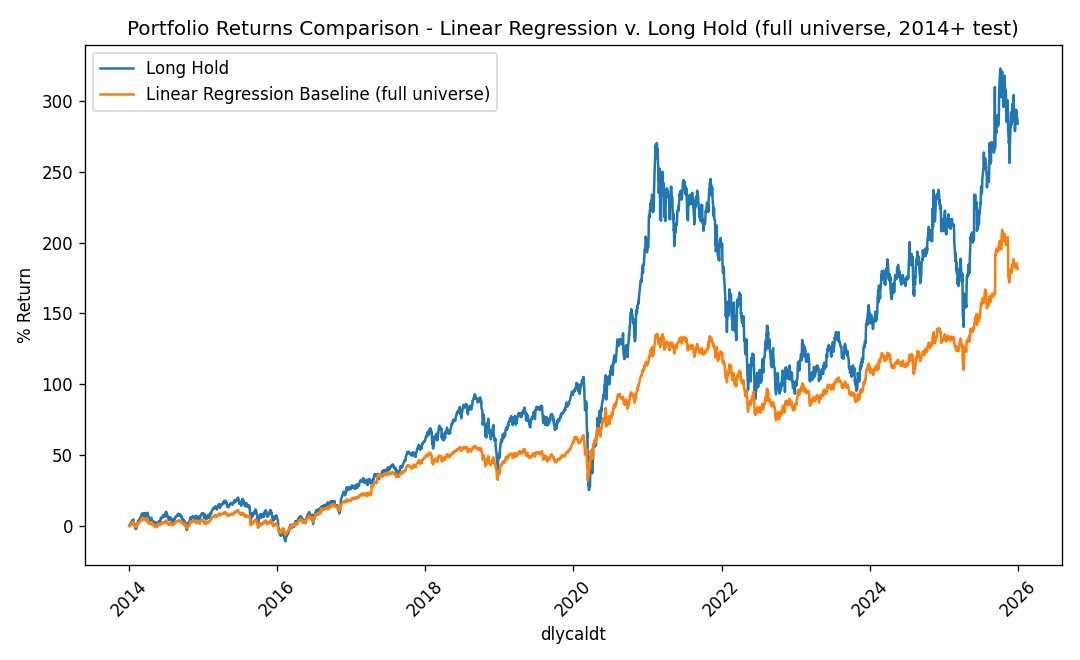

Final Long-Hold % return: 283.87%
Final Strategy % return:  181.25%


In [1]:
plot_df2 = ret_df.groupby(by=DATE_COL).agg({"strat_ret": "sum", "hold_ret": "sum", TICKER_COL1: "count"}).rename(columns={TICKER_COL1: "num_stocks"})
plot_df2['base_bal'] = plot_df2["num_stocks"] * START_BALANCE
plot_df2["strat_pct_grwth"] = (plot_df2["strat_ret"] / plot_df2['base_bal'] - 1) * 100
plot_df2["hold_pct_grwth"] = (plot_df2["hold_ret"] / plot_df2['base_bal'] - 1) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.lineplot(x=plot_df2.index, y=plot_df2['hold_pct_grwth'], label="Long Hold", ax=ax)
sns.lineplot(x=plot_df2.index, y=plot_df2['strat_pct_grwth'], label="Linear Regression Baseline Strategy", ax=ax)
ax.set_title("Portfolio Returns Comparison - Linear Regression Baseline v. Long Hold")
ax.set_ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final Long-Hold % return: {plot_df2['hold_pct_grwth'].iloc[-1]:.2f}%")
print(f"Final Strategy % return:  {plot_df2['strat_pct_grwth'].iloc[-1]:.2f}%")